# jeanie: gradients, ensembles, and existence

Three things the package cannot do, and one it does wrongly.

`jeanie`'s JAX path differentiates the solve by the implicit function theorem,
so a gradient costs about as much as a solve rather than 12 finite-difference
solves. It also answers *whether a solution exists*, which matters more than it
sounds: the matching problem is multi-valued, and roughly 7% of a plausible
prior has no solution at all.

In [1]:
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

import matplotlib.pyplot as plt
import numpy as np

from jeanie.jaxsolver import solve_log, nfw_boundary

# params = (M200, c, r1, Md, a, b)
p = jnp.array([1e12, 10.0, 12.0, 6e10, 3.0, 0.28])
lg = solve_log(p)
print(f"r0 = {float(jnp.exp(lg[0])):.6f} kpc   "
      f"sigma0 = {float(jnp.exp(lg[1])):.4f} km/s")

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


r0 = 1.750607 kpc   sigma0 = 156.5550 km/s


## The Jacobian, in one pass

`jacfwd` gives the full $2\times6$ derivative matrix. Logarithmic derivatives
are the readable form: how much does the core radius move per fractional change
in each parameter?

In [2]:
jac = np.asarray(jax.jacfwd(solve_log)(p))
names = ['M200', 'c', 'r1', 'Md', 'a', 'b']
print("  dlog(r0)/dlog(x)      dlog(sigma0)/dlog(x)")
for i, nm in enumerate(names):
    print(f"  {nm:5s} {jac[0, i]*float(p[i]):+9.4f}            "
          f"{jac[1, i]*float(p[i]):+9.4f}")

  dlog(r0)/dlog(x)      dlog(sigma0)/dlog(x)
  M200    +0.1382              +0.1348
  c       -0.4804              +0.1088
  r1      -0.3577              -0.0688
  Md      +0.0269              +0.2901
  a       +0.7425              -0.1982
  b       +0.1199              -0.0077


## Gradients are exact, not differenced

Against central finite differences of the *numba* solver — a separate
implementation — the agreement plateaus over several decades of step size.
A finite-difference gradient has no such plateau: it is dominated by truncation
at large steps and by round-off at small ones.

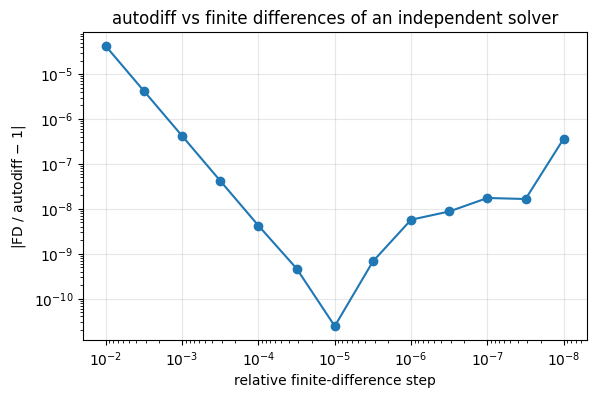

best agreement: 2.44e-11


In [3]:
from jeanie.solver import solve_spherical
GN = 4.302e-6

def numba_log_r0(q):
    M200, c, r1, Md, a, b = [float(v) for v in q]
    rho1, M1 = [float(v) for v in nfw_boundary(M200, c, r1)]
    pb = lambda r, th: -GN * Md / np.sqrt(
        r ** 2 * np.sin(th) ** 2 + (a + np.sqrt(b ** 2 + r ** 2 * np.cos(th) ** 2)) ** 2)
    return np.log(solve_spherical(r1, rho1, M1, Phi_b=pb).r0)

k = 1                                   # concentration
exact = float(jac[0, k])
steps = np.logspace(-2, -8, 13)
errs = []
for s in steps:
    d = np.zeros(6); d[k] = s * float(p[k])
    fd = (numba_log_r0(np.asarray(p) + d) - numba_log_r0(np.asarray(p) - d)) / (2 * d[k])
    errs.append(abs(fd / exact - 1.0))

plt.figure(figsize=(6.5, 4))
plt.loglog(steps, errs, 'o-', c='C0')
plt.xlabel('relative finite-difference step'); plt.ylabel('|FD / autodiff $-$ 1|')
plt.title('autodiff vs finite differences of an independent solver')
plt.grid(alpha=0.3); plt.gca().invert_xaxis(); plt.show()
print(f"best agreement: {min(errs):.2e}")

## A whole ensemble at once

`vmap` turns the solve into a batched kernel, which is what makes a sampler
affordable: the per-halo cost falls by about a factor of four.

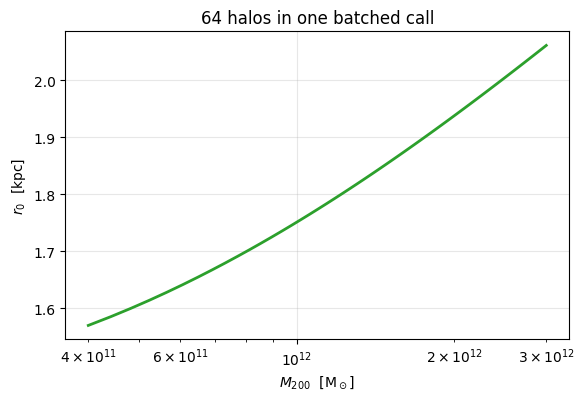

In [4]:
P = jnp.tile(p, (64, 1)).at[:, 0].set(jnp.linspace(4e11, 3e12, 64))
batched = jax.jit(jax.vmap(solve_log))
r0s = np.exp(np.asarray(batched(P))[:, 0])

plt.figure(figsize=(6.5, 4))
plt.semilogx(np.asarray(P)[:, 0], r0s, c='C2', lw=2)
plt.xlabel(r'$M_{200}$  [M$_\odot$]'); plt.ylabel(r'$r_0$  [kpc]')
plt.title('64 halos in one batched call'); plt.grid(alpha=0.3); plt.show()

## Does a solution exist?

The matching problem is the classical isothermal spiral: the matching ratio
$R = M_1/(4\pi r_1^3\rho_1)$ turns over at $R_{\rm MAX} = 1.2615$, so beyond
that there is **no** solution. Between $r_1/r_s = 1.78$ and $3.97$ a solution
exists but it is not unique, and picking the wrong branch gives an answer that
satisfies the equations to $10^{-15}$ while being wrong by orders of magnitude.

`jeanie` solves by bracketing, which cannot reach another branch, and reports
non-existence rather than returning something plausible.

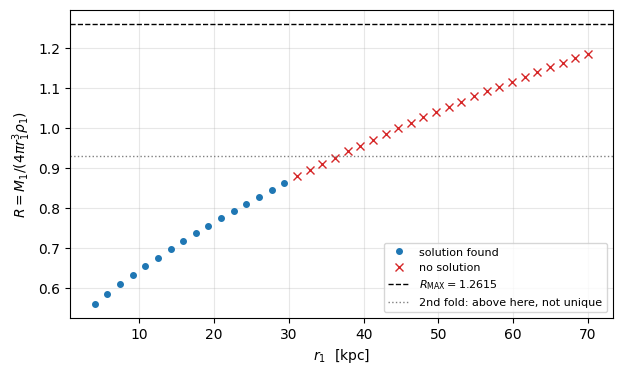

solvable for 16 of 40 matching radii tried


In [5]:
from jeanie import universal
from jeanie.outer import boundary_data
import jeans
from jeans.classes import CDM_profile

Md, a_d, b_d = 6e10, 3.0, 0.28
def Phi_b(r, th):
    return -GN * Md / np.sqrt(
        r ** 2 * np.sin(th) ** 2
        + (a_d + np.sqrt(b_d ** 2 + r ** 2 * np.cos(th) ** 2)) ** 2)

halo = CDM_profile(1e12, 10.0, q0=1.0, Phi_b=Phi_b)
r1s = np.linspace(4.0, 70.0, 40)
Rs, ok = [], []
for x in r1s:
    rho1, M1, _ = boundary_data(halo, float(x), L_list=(0,))
    Rs.append(universal.matching_ratio_of(float(x), rho1, M1))
    ok.append(solve_spherical(float(x), rho1, M1, Phi_b=Phi_b).success)
Rs, ok = np.array(Rs), np.array(ok)

plt.figure(figsize=(7, 4))
plt.plot(r1s[ok], Rs[ok], 'o', ms=4, c='C0', label='solution found')
plt.plot(r1s[~ok], Rs[~ok], 'x', ms=6, c='C3', label='no solution')
plt.axhline(universal.R_MAX, ls='--', c='k', lw=1,
            label=r'$R_{\rm MAX}=1.2615$')
plt.axhline(0.932, ls=':', c='grey', lw=1, label='2nd fold: above here, not unique')
plt.xlabel(r'$r_1$  [kpc]'); plt.ylabel(r'$R = M_1/(4\pi r_1^3\rho_1)$')
plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.show()
print(f"solvable for {ok.sum()} of {len(ok)} matching radii tried")

## Exporting as a potential

What a stream integrator needs is an acceleration, called millions of times per
likelihood. `jeanie` gives it in closed form: the march's second variable is the
enclosed mass, so there is no Poisson solve and nothing to differentiate.
Continuity at $r_1$ is a matching condition, so it is exact.

M(<r1)/M1 - 1 = 2.66e-15   (exact by construction)


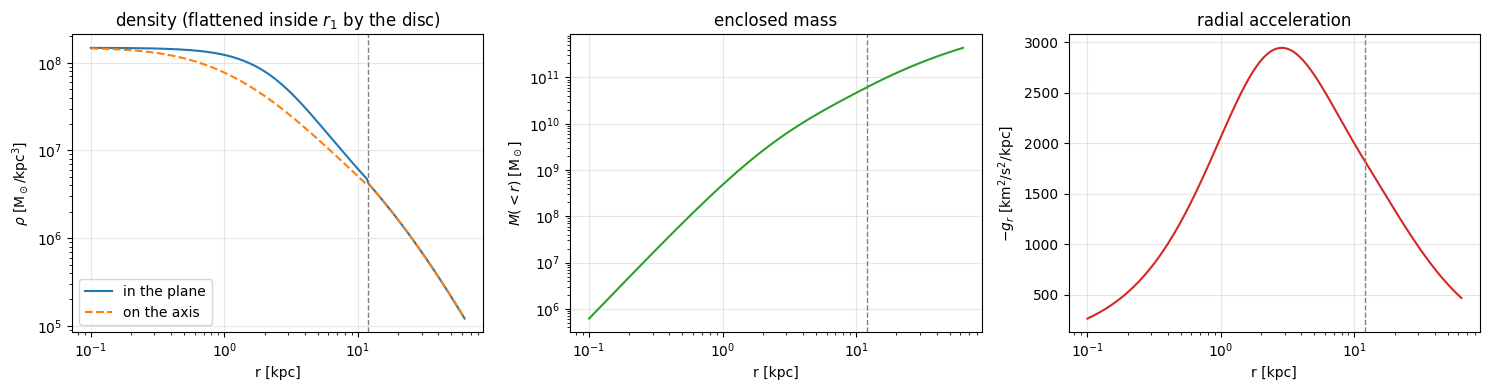

In [6]:
from jeanie import jaxprofile as JP

M = JP.mass_fn(p)
g = JP.radial_acceleration_fn(p)
rho = JP.density_fn(p)
r1v = float(p[2])
M1 = float(nfw_boundary(float(p[0]), float(p[1]), r1v)[1])
print(f"M(<r1)/M1 - 1 = {abs(float(M(r1v))/M1 - 1):.2e}   (exact by construction)")

rr = np.logspace(-1, 1.8, 200)
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs[0].loglog(rr, [float(rho(x, 0.0)) for x in rr], c='C0', label='in the plane')
axs[0].loglog(rr, [float(rho(0.0, x)) for x in rr], c='C1', ls='--', label='on the axis')
axs[0].set_ylabel(r'$\rho$ [M$_\odot$/kpc$^3$]'); axs[0].legend()
axs[1].loglog(rr, [float(M(x)) for x in rr], c='C2')
axs[1].set_ylabel(r'$M(<r)$ [M$_\odot$]')
axs[2].semilogx(rr, [-float(g(x)) for x in rr], c='C3')
axs[2].set_ylabel(r'$-g_r$ [km$^2$/s$^2$/kpc]')
for ax in axs:
    ax.axvline(r1v, ls='--', c='grey', lw=1); ax.set_xlabel('r [kpc]'); ax.grid(alpha=0.3)
axs[0].set_title('density (flattened inside $r_1$ by the disc)')
axs[1].set_title('enclosed mass'); axs[2].set_title('radial acceleration')
plt.tight_layout(); plt.show()

The density is flattened inside $r_1$ because the dark matter feels the
disc there, and spherical outside because this host has $q_0 = 1$. The dashed
line marks $r_1$: nothing discontinuous happens there, which is the point.

In [7]:
dg = jax.grad(lambda q: JP.radial_acceleration_fn(q)(8.0))(p)
print("d g(8 kpc) / dlog x:")
for i, nm in enumerate(['M200', 'c', 'r1', 'Md', 'a', 'b']):
    print(f"  {nm:5s} {float(dg[i])*float(p[i]):+12.3f}")

d g(8 kpc) / dlog x:
  M200      -980.301
  c        -2338.006
  r1        -249.790
  Md         -60.246
  a         +124.637
  b           +6.855
